In [1]:
# === CELL 1: Imports y dependencias ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import gymnasium as gym
from gymnasium import spaces

try:
    from stable_baselines3 import PPO
    from stable_baselines3.common.vec_env import DummyVecEnv
except ImportError:
    print("Instala stable-baselines3 antes de ejecutar este notebook.")

# Breakpoint detection basado en RL quasi-supervisado

- **setup**: tomas dos vectores de entrada: el ndvi y un vector categorico que le indica el landcover (0: bosque, 1: no-bosque)
- **idea**: la ieda es que el sistema tenga dos estados, y aprende a seguir la serie de tiempo en cada uno de ellos.
- **como se usa**: si entrena, se puede cambiar el input de 0 a 1 a ver a que modelo ajusta mejor

### Levanto series verdaderas de NDVI

In [2]:
filename = 'sitio1_deforestacion_train.csv'
dataFolder = 'SERIES_NUEVAS/'
df = pd.read_csv(dataFolder+filename)

In [3]:
df.columns.values

array(['Unnamed: 0', 'lon', 'lat', 'sitio', 'anio', 'mes', 'nubes',
       '2000-02-18', '2000-03-05', '2000-03-21', '2000-04-06',
       '2000-04-22', '2000-05-08', '2000-05-24', '2000-06-09',
       '2000-06-25', '2000-07-11', '2000-07-27', '2000-08-12',
       '2000-08-28', '2000-09-13', '2000-09-29', '2000-10-15',
       '2000-10-31', '2000-11-16', '2000-12-02', '2000-12-18',
       '2001-01-01', '2001-01-17', '2001-02-02', '2001-02-18',
       '2001-03-06', '2001-03-22', '2001-04-07', '2001-04-23',
       '2001-05-09', '2001-05-25', '2001-06-10', '2001-06-26',
       '2001-07-12', '2001-07-28', '2001-08-13', '2001-08-29',
       '2001-09-14', '2001-09-30', '2001-10-16', '2001-11-01',
       '2001-11-17', '2001-12-03', '2001-12-19', '2002-01-01',
       '2002-01-17', '2002-02-02', '2002-02-18', '2002-03-06',
       '2002-03-22', '2002-04-07', '2002-04-23', '2002-05-09',
       '2002-05-25', '2002-06-10', '2002-06-26', '2002-07-12',
       '2002-07-28', '2002-08-13', '2002-08-29', '

Ploteo eventos de deforestacion

In [4]:
ndviDataStart = 7
testPixel = np.arange(0,50)

### reconstruyo vector fechas

In [5]:
fechas = pd.to_datetime(df.columns[ndviDataStart:])


### Incluyo fecha deforestacion

In [6]:
df['fechaDef'] = pd.to_datetime({
    'year': df['anio'].astype(int),
    'month': df['mes'].astype(int),
    'day': 1
})

#### reordeno columna

In [7]:
col = df.pop('fechaDef')
df.insert(1, 'fechaDef', col)

In [8]:
df

,Unnamed: 0,fechaDef,lon,lat,sitio,anio,mes,nubes,2000-02-18,2000-03-05,...,2018-05-25,2018-06-10,2018-06-26,2018-07-12,2018-07-28,2018-08-13,2018-08-29,2018-09-14,2018-09-30,2018-10-16
0,0,2012-06-01,-63.090370,-25.042652,1.0,2012.0,6.0,0.0,0.4052,0.366167,...,0.2710,0.1923,0.2186,0.1878,0.1518,0.1496,0.1639,0.15950,0.1634,0.3735
1,1,2012-06-01,-63.088070,-25.042652,1.0,2012.0,6.0,0.0,0.4098,0.371700,...,0.2710,0.1935,0.2186,0.1777,0.1468,0.1597,0.1745,0.18590,0.1543,0.3981
2,2,2012-06-01,-63.085771,-25.042652,1.0,2012.0,6.0,0.0,0.4156,0.376000,...,0.2879,0.2050,0.2131,0.1896,0.1546,0.1597,0.1620,0.15510,0.1543,0.3981
3,4,2012-06-01,-63.081172,-25.042652,1.0,2012.0,6.0,0.0,0.4236,0.387333,...,0.2938,0.1944,0.2257,0.1864,0.1557,0.1622,0.1518,0.14760,0.1630,0.4007
4,5,2012-06-01,-63.078872,-25.042652,1.0,2012.0,6.0,0.0,0.4252,0.388200,...,0.2822,0.1773,0.2205,0.1724,0.1429,0.1555,0.1588,0.14520,0.1795,0.3924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4605,5757,2013-08-01,-62.970028,-25.392651,1.0,2013.0,8.0,0.0,0.3661,0.366100,...,0.2491,0.2040,0.2330,0.1758,0.1567,0.1599,0.1482,0.16100,0.1483,0.3382
4606,5758,2013-08-01,-62.968809,-25.394735,1.0,2013.0,8.0,0.0,0.3370,0.337000,...,0.2811,0.2147,0.2321,0.1984,0.1659,0.1639,0.1564,0.17860,0.1653,0.3339
4607,5759,2013-08-01,-62.969896,-25.396818,1.0,2013.0,8.0,0.0,0.4503,0.370950,...,0.2830,0.2061,0.2355,0.1951,0.1620,0.1643,0.1542,0.15950,0.1648,0.3430
4608,5761,2013-08-01,-62.968677,-25.398901,1.0,2013.0,8.0,0.0,0.4493,0.376150,...,0.2632,0.2074,0.2225,0.1851,0.1586,0.1520,0.1678,0.16405,0.1603,0.3377


In [9]:
ndviDataStart+=1

### Grafico datos

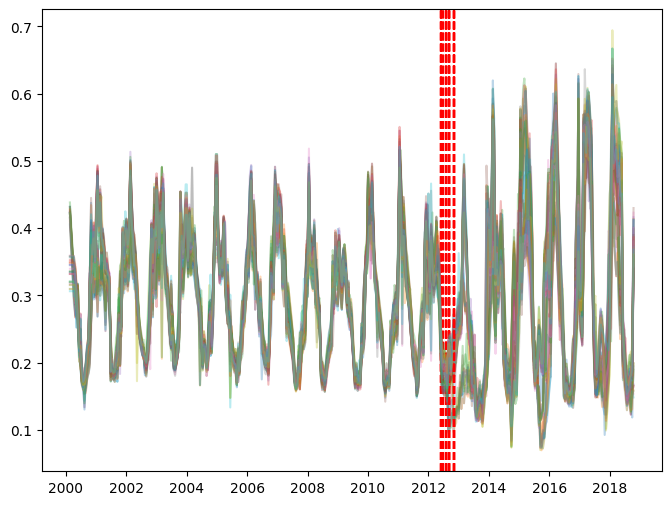

In [10]:
from datetime import datetime

fig, ax = plt.subplots(figsize=(8, 6))

df2 = pd.DataFrame()
df2['fechas'] = fechas

for pixel in testPixel:

    # deforestationDate = datetime(int(df['anio'].iloc[pixel]), int(df['mes'].iloc[pixel]), 1)
    deforestationDate = df['fechaDef'].iloc[pixel]
    ndvi = df.iloc[pixel, ndviDataStart:].values

    df2[pixel] = ndvi

    ax.plot(fechas, ndvi, alpha = 0.3)
    ax.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')

### Normalizo NDVI

In [11]:
# === CELL 3: Preprocesamiento y split ===
# Normalización [-1,1]
ndvi = df2.iloc[:,1:].values
minv, maxv = ndvi.min(), ndvi.max()
def normalize(x): return 2*(x - minv)/(maxv - minv) - 1
def denormalize(z): return ((z+1)/2*(maxv - minv)) + minv

# df['ndvi_norm'] = normalize(ndvi)
ndvi_norm = df2.iloc[:,1:].apply(normalize)

### Por el momento no hago split

In [12]:
# mask = (fechas.year == deforestationDate.year) & (fechas.month == deforestationDate.month)
# deforestationDate = np.where(mask)[0][0]
# train_df = ndvi_norm.iloc[:deforestationDate].reset_index(drop=True)
# test_df = ndvi_norm.iloc[deforestationDate:].reset_index(drop=True)
ndvi_norm

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.074756,0.089483,0.108052,0.133664,0.138787,0.129822,0.108052,0.108052,0.12534,0.130463,...,-0.151273,-0.107732,-0.148391,-0.102609,-0.117656,-0.160557,-0.160557,-0.213382,-0.212422,-0.077637
1,-0.050211,-0.032496,-0.018729,0.017555,0.02033,0.017982,0.015848,0.01478,0.027373,0.034417,...,-0.151273,-0.107732,-0.148391,-0.102609,-0.117656,-0.160557,-0.160557,-0.213382,-0.212422,-0.077637
2,-0.175177,-0.154474,-0.14551,-0.098554,-0.098127,-0.093858,-0.076357,-0.078491,-0.070594,-0.06163,...,-0.151273,-0.107732,-0.148391,-0.102609,-0.117656,-0.160557,-0.160557,-0.213382,-0.212422,-0.077637
3,-0.300144,-0.276453,-0.272291,-0.214663,-0.216584,-0.205699,-0.168561,-0.171762,-0.168561,-0.157676,...,-0.151273,-0.107732,-0.148391,-0.102609,-0.117656,-0.160557,-0.160557,-0.213382,-0.212422,-0.077637
4,-0.344645,-0.305907,-0.360973,-0.367376,-0.35457,-0.305907,-0.300784,-0.2915,-0.287338,-0.206979,...,-0.18681,-0.14679,-0.134625,-0.12598,-0.180407,-0.160557,-0.160557,-0.213382,-0.212422,-0.151273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425,-0.743557,-0.711221,-0.711221,-0.703218,-0.724668,-0.744517,-0.763086,-0.763086,-0.774292,-0.743877,...,-0.662238,-0.722107,-0.599168,-0.677925,-0.691372,-0.746438,-0.746438,-0.717945,-0.689451,-0.719866
426,-0.697775,-0.663839,-0.703858,-0.736514,-0.714103,-0.671522,-0.730431,-0.754122,-0.724348,-0.673123,...,-0.611654,-0.657115,-0.546022,-0.652633,-0.665439,-0.653594,-0.653594,-0.668001,-0.661277,-0.702897
427,-0.711862,-0.627341,-0.725948,-0.74996,-0.757644,-0.754442,-0.658716,-0.658716,-0.778454,-0.653914,...,-0.650712,-0.651673,-0.594685,-0.630543,-0.628622,-0.657436,-0.638547,-0.638547,-0.640467,-0.662238
428,-0.699376,-0.72851,-0.72851,-0.700656,-0.647831,-0.544741,-0.561069,-0.700656,-0.703858,-0.544101,...,-0.60333,-0.638226,-0.546983,-0.58252,-0.58252,-0.539299,-0.586361,-0.62414,-0.465984,-0.617416


In [13]:
train_df = ndvi_norm

In [14]:
train_df

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.074756,0.089483,0.108052,0.133664,0.138787,0.129822,0.108052,0.108052,0.12534,0.130463,...,-0.151273,-0.107732,-0.148391,-0.102609,-0.117656,-0.160557,-0.160557,-0.213382,-0.212422,-0.077637
1,-0.050211,-0.032496,-0.018729,0.017555,0.02033,0.017982,0.015848,0.01478,0.027373,0.034417,...,-0.151273,-0.107732,-0.148391,-0.102609,-0.117656,-0.160557,-0.160557,-0.213382,-0.212422,-0.077637
2,-0.175177,-0.154474,-0.14551,-0.098554,-0.098127,-0.093858,-0.076357,-0.078491,-0.070594,-0.06163,...,-0.151273,-0.107732,-0.148391,-0.102609,-0.117656,-0.160557,-0.160557,-0.213382,-0.212422,-0.077637
3,-0.300144,-0.276453,-0.272291,-0.214663,-0.216584,-0.205699,-0.168561,-0.171762,-0.168561,-0.157676,...,-0.151273,-0.107732,-0.148391,-0.102609,-0.117656,-0.160557,-0.160557,-0.213382,-0.212422,-0.077637
4,-0.344645,-0.305907,-0.360973,-0.367376,-0.35457,-0.305907,-0.300784,-0.2915,-0.287338,-0.206979,...,-0.18681,-0.14679,-0.134625,-0.12598,-0.180407,-0.160557,-0.160557,-0.213382,-0.212422,-0.151273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425,-0.743557,-0.711221,-0.711221,-0.703218,-0.724668,-0.744517,-0.763086,-0.763086,-0.774292,-0.743877,...,-0.662238,-0.722107,-0.599168,-0.677925,-0.691372,-0.746438,-0.746438,-0.717945,-0.689451,-0.719866
426,-0.697775,-0.663839,-0.703858,-0.736514,-0.714103,-0.671522,-0.730431,-0.754122,-0.724348,-0.673123,...,-0.611654,-0.657115,-0.546022,-0.652633,-0.665439,-0.653594,-0.653594,-0.668001,-0.661277,-0.702897
427,-0.711862,-0.627341,-0.725948,-0.74996,-0.757644,-0.754442,-0.658716,-0.658716,-0.778454,-0.653914,...,-0.650712,-0.651673,-0.594685,-0.630543,-0.628622,-0.657436,-0.638547,-0.638547,-0.640467,-0.662238
428,-0.699376,-0.72851,-0.72851,-0.700656,-0.647831,-0.544741,-0.561069,-0.700656,-0.703858,-0.544101,...,-0.60333,-0.638226,-0.546983,-0.58252,-0.58252,-0.539299,-0.586361,-0.62414,-0.465984,-0.617416


#### Definicion listas de train y test

In [15]:
train_list = []
test_list = []
nTrain = 20
for i in range(nTrain):
    train_list.append(train_df[i].values)

nTest = 20
for i in range(nTest):
    test_list.append(train_df[i+nTrain].values)

### Definicion Entorno gym.Env para que tome stable_baselines3

In [16]:
# class NDVIMultiEnv_vec(gym.Env):
#     def __init__(self, series_data, window=23):
#         """
#         Args:
#             series_data: numpy array of shape (2, length_series, num_series)
#                         First index: 0=NDVI, 1=binary class
#                         Second index: temporal length
#                         Third index: number of different series
#         """
#         super().__init__()
        
#         # Convertir y validar entrada
#         self.series_data = np.array(series_data, dtype=np.float32)
#         assert len(self.series_data.shape) == 3, "Input must be 3D array"
#         assert self.series_data.shape[0] == 2, "First dimension must be 2 (NDVI and class)"
        
#         self.n_features = 2
#         self.n_series = self.series_data.shape[2]
#         self.length = self.series_data.shape[1]
#         self.window = window
        
#         # Current episode tracking
#         self.current_series = 0
#         self.current_step = self.window

#         # Espacios de observación y acción
#         self.observation_space = spaces.Dict({
#             'continuous': spaces.Box(
#                 low=-1.5, high=1.5,
#                 shape=(self.window,),
#                 dtype=np.float32
#             ),
#             'categorical': spaces.Box(
#                 low=0, high=1,
#                 shape=(self.window,),
#                 dtype=np.float32
#             )
#         })

#         self.action_space = spaces.Dict({
#             'continuous': spaces.Box(
#                 low=-1.5, high=1.5,
#                 shape=(1,),
#                 dtype=np.float32
#             ),
#             'categorical': spaces.Discrete(2)
#         })

#     def reset(self, seed=None, options=None):
#         super().reset(seed=seed)
        
#         # Reset steps and randomly select a new series
#         self.current_step = self.window
#         self.current_series = self.np_random.integers(0, self.n_series)
        
#         # Get initial window of observations
#         obs = {
#             'continuous': self.series_data[0, self.current_step-self.window:self.current_step, self.current_series],
#             'categorical': self.series_data[1, self.current_step-self.window:self.current_step, self.current_series]
#         }
        
#         return obs, {}

#     def step(self, action):
#         # Get current targets
#         target_continuous = self.series_data[0, self.current_step, self.current_series]
#         target_categorical = self.series_data[1, self.current_step, self.current_series]
        
#         # Calculate rewards
#         reward_continuous = -(action['continuous'][0] - target_continuous) ** 2
#         reward_categorical = float(action['categorical'] == int(target_categorical))
#         reward = 0.7 * reward_continuous + 0.3 * reward_categorical
        
#         # Advance step
#         self.current_step += 1
        
#         # Check if episode is done
#         done = self.current_step >= self.length
        
#         # Get next observation
#         if not done:
#             next_obs = {
#                 'continuous': self.series_data[0, self.current_step-self.window:self.current_step, self.current_series],
#                 'categorical': self.series_data[1, self.current_step-self.window:self.current_step, self.current_series]
#             }
#         else:
#             next_obs = {
#                 'continuous': np.zeros(self.window, dtype=np.float32),
#                 'categorical': np.zeros(self.window, dtype=np.float32)
#             }
        
#         return next_obs, reward, done, False, {}

In [17]:
# class NDVIMultiEnv_vec(gym.Env):
#     def __init__(self, series_data, window=23, normalize=False):
#         """
#         Args:
#             series_data: numpy array of shape (n_features, n_series, length)
#                          Ejemplo: (2, 45, 430)
#             window: tamaño de la ventana temporal
#             normalize: si True, normaliza cada feature entre -1 y 1
#         """
#         super().__init__()

#         self.series_data = np.array(series_data, dtype=np.float32)
#         assert len(self.series_data.shape) == 3, "Input must be 3D: (features, series, length)"
        
#         self.n_features, self.n_series, self.length = self.series_data.shape
#         self.window = window

#         if normalize:
#             # Normalizar por feature globalmente
#             min_vals = self.series_data.min(axis=(1,2), keepdims=True)
#             max_vals = self.series_data.max(axis=(1,2), keepdims=True)
#             self.series_data = 2 * (self.series_data - min_vals) / (max_vals - min_vals + 1e-8) - 1

#         self.current_step = self.window

#         # Observación continua 3D: (window, n_features, n_series)
#         obs_shape = (self.window, self.n_features, self.n_series)
#         self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=obs_shape, dtype=np.float32)

#         # Acción continua: predice un vector (n_features, n_series)
#         self.action_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.n_features, self.n_series), dtype=np.float32)

#     def reset(self, seed=None, options=None):
#         super().reset(seed=seed)
#         self.current_step = self.window
        
#         obs = self.series_data[:, :, self.current_step - self.window:self.current_step]
#         obs = np.transpose(obs, (2, 0, 1))  # (window, n_features, n_series)
#         return obs.astype(np.float32), {}

#     def step(self, action):
#         target = self.series_data[:, :, self.current_step]  # (n_features, n_series)

#         # Recompensa = negativo del MSE total
#         mse = np.mean((action - target) ** 2)
#         reward = -mse

#         self.current_step += 1
#         done = self.current_step >= self.length

#         if not done:
#             obs = self.series_data[:, :, self.current_step - self.window:self.current_step]
#             obs = np.transpose(obs, (2, 0, 1))
#         else:
#             obs = np.zeros((self.window, self.n_features, self.n_series), dtype=np.float32)

#         return obs.astype(np.float32), reward, done, False, {}



In [18]:
class NDVIMultiEnv_vec(gym.Env):
    def __init__(self, series_data, window=23, normalize=False):
        """
        Args:
            series_data: numpy array of shape (n_features, n_series, length)
                         Ejemplo: (2, 45, 430)
            window: tamaño de la ventana temporal
            normalize: si True, normaliza cada feature entre -1 y 1
        """
        super().__init__()

        self.series_data = np.array(series_data, dtype=np.float32)
        assert len(self.series_data.shape) == 3, "Input must be 3D: (features, series, length)"
        
        self.n_features, self.n_series, self.length = self.series_data.shape
        self.window = window

        if normalize:
            # Normalizar por feature globalmente
            min_vals = self.series_data.min(axis=(1,2), keepdims=True)
            max_vals = self.series_data.max(axis=(1,2), keepdims=True)
            self.series_data = 2 * (self.series_data - min_vals) / (max_vals - min_vals + 1e-8) - 1

        self.current_step = self.window

        # Observación continua 3D: (window, n_features, n_series)
        obs_shape = (self.window, self.n_features, self.n_series)
        self.observation_space = spaces.Box(low=-1.5, high=1.5, shape=obs_shape, dtype=np.float32)

        # Acción continua acotada: predice (n_features, n_series)
        self.action_space = spaces.Box(low=-2.0, high=2.0, shape=(self.n_features, self.n_series), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window
        
        obs = self.series_data[:, :, self.current_step - self.window:self.current_step]
        obs = np.transpose(obs, (2, 0, 1))  # (window, n_features, n_series)
        return obs.astype(np.float32), {}

    def step(self, action):
        target = self.series_data[:, :, self.current_step]  # (n_features, n_series)

        # Clampeamos acción a rango permitido (opcional)
        action = np.clip(action, self.action_space.low, self.action_space.high)

        # Recompensa = negativo del MSE total
        mse = np.mean((action - target) ** 2)
        reward = -mse

        self.current_step += 1
        done = self.current_step >= self.length

        if not done:
            obs = self.series_data[:, :, self.current_step - self.window:self.current_step]
            obs = np.transpose(obs, (2, 0, 1))
        else:
            obs = np.zeros((self.window, self.n_features, self.n_series), dtype=np.float32)

        return obs.astype(np.float32), reward, done, False, {}

### Sintetizo serie booleana

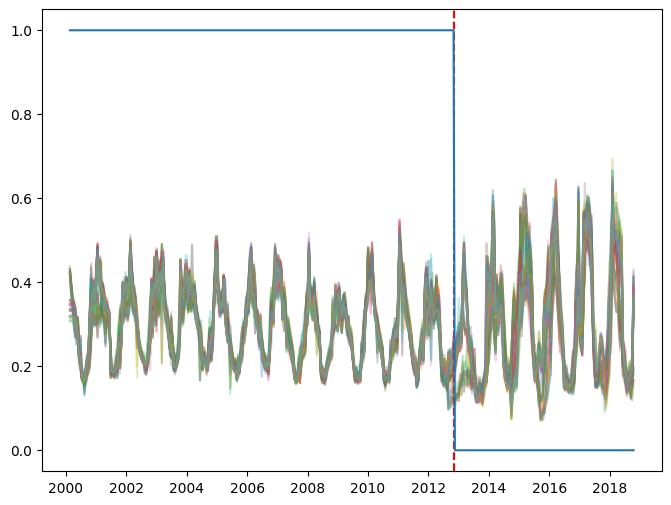

In [19]:
''' # Ejemplo: tres series de NDVI simuladas
t = np.linspace(0, 4*np.pi, 200)
serie1 = np.sin(t)
serie2 = np.sin(t + 0.5)
serie3 = np.sin(t - 0.7)
series_list = [serie1, serie2, serie3] '''

input2 = fechas < deforestationDate
input2 = [np.float64(1.0) if x == True else 0 for x in input2]

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fechas, ndvi, alpha = 0.3)
ax.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')
ax.plot(fechas, input2)

### Pego las series

In [20]:
len(train_df)

430

In [21]:
series_list = []
for i in train_list:
    series_list.append((i, input2))
series_list = np.asarray(series_list)
series_list = series_list.reshape((2, nTrain, len(fechas)))

In [22]:
series_list.shape

(2, 20, 430)

## Entrenamiento

In [23]:
# Crear entorno
env = NDVIMultiEnv_vec(series_list, window=23)

In [24]:

obs, _ = env.reset()
print("Forma de observación:", obs.shape)

Forma de observación: (23, 2, 20)


In [25]:
obs.shape

(23, 2, 20)

In [26]:
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=100_000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 407      |
|    ep_rew_mean     | -551     |
| time/              |          |
|    fps             | 1824     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 407         |
|    ep_rew_mean          | -549        |
| time/                   |             |
|    fps                  | 2053        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.021407427 |
|    clip_fraction        | 0.273       |
|    clip_range           | 0.2         |
|    entropy_loss   

## Evaluacion

### evaluacion con Train (si no anda estamos en el horno)

### Evaluacion con Test

In [ ]:
# # Create test environment with one of the test series plus the boolean input
# test_input = [test_list, input2]  # Using first test series and same boolean input
# test_env = NDVIMultiEnv_vec(test_input, window=23)

# # Reset environment and prepare for evaluation
# obs, _ = test_env.reset()
# preds = []
# rewards = []

# # Run predictions
# done = False
# while not done:
#     action, _ = model.predict(obs, deterministic=True)
#     obs, reward, done, _, _ = test_env.step(action)
#     preds.append(action)
#     rewards.append(reward)

# # Convert predictions to numpy array
# preds = np.array(preds)
# true_vals = test_env.data[test_env.window:test_env.window + len(preds)]

# # Plot results for each variable
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# # Plot NDVI series
# ax1.plot(true_vals[:, 0], label="Real NDVI", color='blue')
# ax1.plot(preds[:, 0], '--', label="Predicted NDVI", color='red')
# ax1.set_title("NDVI Comparison")
# ax1.legend()
# ax1.set_ylabel("Normalized NDVI")

# # Plot boolean input series
# ax2.plot(true_vals[:, 1], label="Real Class", color='green')
# ax2.plot(preds[:, 1], '--', label="Predicted Class", color='orange')
# ax2.set_title("Class Prediction")
# ax2.legend()
# ax2.set_ylabel("Class (0: Forest, 1: Non-forest)")
# ax2.set_xlabel("Timestep")
# plt.tight_layout()
# plt.show()

## Cosas por hacer
### Definir bien el punto de quiebre para cada serie, y hacer el vector input2 correspondiente
### Modificar el entorno para evaluar ed a una serie


### Genero el vector de test

In [27]:
test_input = []
for i in test_list:
    test_input.append((i, input2))


In [ ]:
test_input = np.asarray(test_input)

In [34]:
test_input.shape

(2, 20, 430)

In [29]:
test_input = test_input.reshape((2, nTest, len(fechas)))

Obs shape inicial: (23, 2, 20)


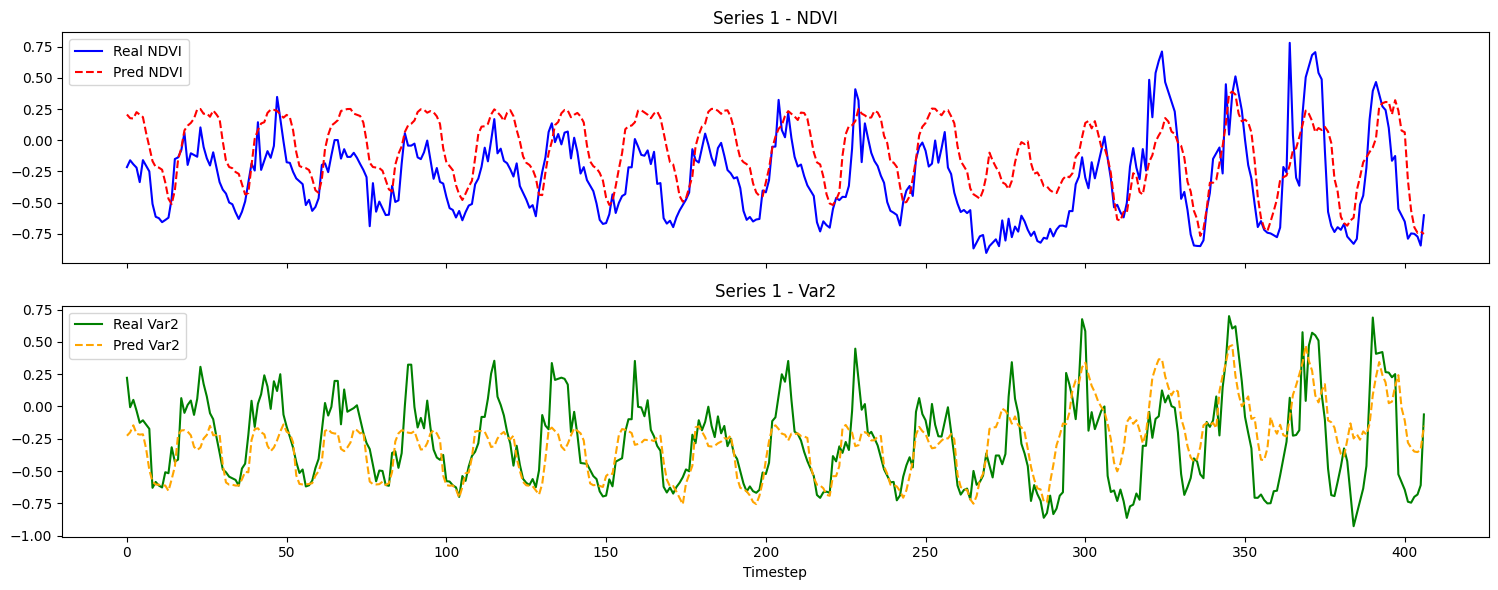

Reward medio: -0.2052


In [31]:
# Crear entorno de test
# test_input = np.stack([np.asarray(test_list[0]), np.asarray(input2)], axis=0)  # Shape (n_features, n_series, length)
test_env = NDVIMultiEnv_vec(test_input, window=23)

# Resetear entorno
obs, _ = test_env.reset()
print("Obs shape inicial:", obs.shape)
preds = []
rewards = []

# Ejecutar política entrenada
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = test_env.step(action)
    preds.append(action)
    rewards.append(reward)

# Convertir a arrays
preds = np.array(preds)  # Shape: (timesteps, n_features, n_series)
rewards = np.array(rewards)

# Extraer los valores reales correspondientes
start = test_env.window
end = start + len(preds)
true_vals = np.transpose(test_env.series_data[:, :, start:end], (2, 0, 1))  # (timesteps, n_features, n_series)

# Graficar resultados para una o más series
n_series_to_plot = min(1, test_env.n_series)  # por ejemplo, mostrar solo las 3 primeras
time_axis = np.arange(len(preds))

fig, axes = plt.subplots(2, n_series_to_plot, figsize=(15, 6), sharex=True)
if n_series_to_plot == 1:
    axes = axes.reshape(2, 1)

for i in range(n_series_to_plot):
    # NDVI (feature 0)
    axes[0, i].plot(time_axis, true_vals[:, 0, i], label="Real NDVI", color='blue')
    axes[0, i].plot(time_axis, preds[:, 0, i], '--', label="Pred NDVI", color='red')
    axes[0, i].set_title(f"Series {i+1} - NDVI")
    axes[0, i].legend()

    # Segunda variable (feature 1)
    axes[1, i].plot(time_axis, true_vals[:, 1, i], label="Real Var2", color='green')
    axes[1, i].plot(time_axis, preds[:, 1, i], '--', label="Pred Var2", color='orange')
    axes[1, i].set_title(f"Series {i+1} - Var2")
    axes[1, i].legend()

axes[1, 0].set_xlabel("Timestep")
plt.tight_layout()
plt.show()

# Mostrar reward promedio
print(f"Reward medio: {np.mean(rewards):.4f}")


In [33]:
true_vals.shape

(407, 2, 20)

### Evaluaciones raras confundiendo

#### Es particular, le digo que sigue en estado bosque a ver que hace

In [ ]:
input3 = np.ones(len(input2), dtype=np.float32)

In [ ]:
input3.shape

In [ ]:
preds.shape

In [ ]:
# Create test environment with one of the test series plus the boolean input
test_input = [test_list[0], input3]  # Using first test series and altered boolean input
test_env = NDVIMultiEnv(test_input, window=23)

# Reset environment and prepare for evaluation
obs, _ = test_env.reset()
preds = []
rewards = []

# Run predictions
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = test_env.step(action)
    preds.append(action)
    rewards.append(reward)

# Convert predictions to numpy array
preds = np.array(preds)
true_vals = test_env.data[test_env.window:test_env.window + len(preds)]

# Plot results for each variable
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot NDVI series
ax1.plot(fechas[23:], true_vals[:, 0], label="Real NDVI", color='green')
ax1.plot(fechas[23:], preds[:, 0], '--', label="Predicted NDVI", color='blue')
ax1.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')
ax1.set_title("NDVI Comparison")
ax1.legend()
ax1.set_ylabel("Normalized NDVI")

# Plot boolean input series
ax2.plot(fechas[23:], true_vals[:, 1], label="Real Class", color='green')
ax2.plot(fechas[23:], preds[:, 1], '--', label="Predicted Class", color='orange')
ax2.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')
ax2.set_title("Class Prediction")
ax2.legend()
ax2.set_ylabel("Class (0: Forest, 1: Non-forest)")
ax2.set_xlabel("Timestep")
ax2.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

In [ ]:
input4 = np.zeros(len(input2), dtype=np.float32)

In [ ]:
# Create test environment with one of the test series plus the boolean input
test_input = [test_list[0], input4]  # Using first test series and same boolean input
test_env = NDVIMultiEnv(test_input, window=23)

# Reset environment and prepare for evaluation
obs, _ = test_env.reset()
preds = []
rewards = []

# Run predictions
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = test_env.step(action)
    preds.append(action)
    rewards.append(reward)

# Convert predictions to numpy array
preds = np.array(preds)
true_vals = test_env.data[test_env.window:test_env.window + len(preds)]

# Plot results for each variable
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot NDVI series
ax1.plot(fechas[23:], true_vals[:, 0], label="Real NDVI", color='blue')
ax1.plot(fechas[23:], preds[:, 0], '--', label="Predicted NDVI", color='red')
ax1.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')
ax1.set_title("NDVI Comparison")
ax1.legend()
ax1.set_ylabel("Normalized NDVI")

# Plot boolean input series
ax2.plot(fechas[23:], true_vals[:, 1], label="Real Class", color='green')
ax2.plot(fechas[23:], preds[:, 1], '--', label="Predicted Class", color='orange')
ax2.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')
ax2.set_title("Class Prediction")
ax2.legend()
ax2.set_ylabel("Class (0: Forest, 1: Non-forest)")
ax2.set_xlabel("Timestep")
ax2.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()